# Catalog intro: build → query → load on synthetic GeoTIFFs

This notebook walks the canonical `geotoolz.catalog` flow. We build a
small raster catalog from synthetic on-disk GeoTIFFs (no real data
required), inspect the underlying `GeoDataFrame`, run spatial and
temporal queries, and load matching rows into a `GeoTensor`.

Array shapes and catalog row counts are tracked at every step.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_bounds

import geotoolz as gz

## A grid of synthetic UTM 29N tiles

Four 32×32 tiles arranged in a 2×2 mosaic over the Iberian peninsula,
captured on four consecutive days.

In [2]:
tmp = Path(tempfile.mkdtemp(prefix="geotoolz_catalog_"))
print(f"workdir: {tmp}")

CHIP = 32  # tile size, in pixels
RES = 10.0  # 10 m per pixel
ORIGIN = (500_000, 4_000_000)


def write_tile(row_idx: int, col_idx: int, date_str: str, value: int) -> Path:
    x0 = ORIGIN[0] + col_idx * CHIP * RES
    y0 = ORIGIN[1] + row_idx * CHIP * RES
    bounds = (x0, y0, x0 + CHIP * RES, y0 + CHIP * RES)
    transform = from_bounds(*bounds, CHIP, CHIP)
    path = tmp / f"S2_T29SND_{date_str}_r{row_idx}_c{col_idx}.tif"
    data = np.full((3, CHIP, CHIP), value, dtype=np.uint16)
    with rasterio.open(
        path,
        "w",
        driver="GTiff",
        height=CHIP,
        width=CHIP,
        count=3,
        dtype="uint16",
        crs="EPSG:32629",
        transform=transform,
    ) as dst:
        dst.write(data)
    return path


paths = [
    write_tile(0, 0, "20240115", value=10),
    write_tile(0, 1, "20240115", value=20),
    write_tile(1, 0, "20240116", value=30),
    write_tile(1, 1, "20240117", value=40),
]
print(f"wrote {len(paths)} GeoTIFFs to {tmp}")
for p in paths:
    print(f"  {p.name}")

workdir: /var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geotoolz_catalog_gm0aslkw
wrote 4 GeoTIFFs to /var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geotoolz_catalog_gm0aslkw
  S2_T29SND_20240115_r0_c0.tif
  S2_T29SND_20240115_r0_c1.tif
  S2_T29SND_20240116_r1_c0.tif
  S2_T29SND_20240117_r1_c1.tif


## Build the catalog

`build_raster_catalog` reads each file's bounds (via `rasterio`) and a
date from the filename via the `(?P<date>...)` named group.

In [3]:
catalog = gz.build_raster_catalog(
    paths,
    filename_regex=r"S2_T29SND_(?P<date>\d{8}).*\.tif",
    target_crs="EPSG:32629",
)
print(f"len(catalog): {len(catalog)}        # 4 rows")
print(f"catalog.backend: {catalog.backend!r}")
print(f"catalog.total_bounds: {catalog.total_bounds}")
print(f"catalog.temporal_extent: {catalog.temporal_extent}")

len(catalog): 4        # 4 rows
catalog.backend: 'raster'
catalog.total_bounds: (500000.0, 4000000.0, 500640.0, 4000640.0)
catalog.temporal_extent: [2024-01-15 00:00:00, 2024-01-17 23:59:59.999999]


Inspect the underlying `GeoDataFrame` — one row per file with a
`geometry` column (footprint polygon) and an `IntervalIndex` row index
carrying the time interval.

In [4]:
catalog.gdf

,filepath,geometry,start_time,end_time,crs
datetime,,,,,
"[2024-01-15 00:00:00, 2024-01-15 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((500320 4000000, 500320 4000320, 5000...",2024-01-15,2024-01-15 23:59:59.999999,EPSG:32629
"[2024-01-15 00:00:00, 2024-01-15 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((500640 4000000, 500640 4000320, 5003...",2024-01-15,2024-01-15 23:59:59.999999,EPSG:32629
"[2024-01-16 00:00:00, 2024-01-16 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((500320 4000320, 500320 4000640, 5000...",2024-01-16,2024-01-16 23:59:59.999999,EPSG:32629
"[2024-01-17 00:00:00, 2024-01-17 23:59:59.999999]",/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn...,"POLYGON ((500640 4000320, 500640 4000640, 5003...",2024-01-17,2024-01-17 23:59:59.999999,EPSG:32629


## Query

Build a `GeoSlice` and ask the catalog which rows it intersects.

In [5]:
aoi = gz.GeoSlice(
    bounds=(500_000, 4_000_000, 500_320, 4_000_320),  # bottom-left tile
    interval=pd.Interval(
        pd.Timestamp("2024-01-15"),
        pd.Timestamp("2024-01-15 23:59"),
        closed="both",
    ),
    resolution=(10.0, 10.0),
    crs="EPSG:32629",
)
hits = catalog.query(aoi)
print(f"len(hits): {len(hits)}              # 1 row — single tile on Jan 15")
print(hits.gdf["filepath"].iloc[0])

len(hits): 2              # 1 row — single tile on Jan 15
/var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geotoolz_catalog_gm0aslkw/S2_T29SND_20240115_r0_c0.tif


### Cross-CRS query

The same query, but with the AOI in EPSG:4326. The catalog reprojects
the bbox internally — the §10.1 footgun in the design plan exists to
avoid silently empty results when the AOI is in the wrong CRS.

In [6]:
aoi_4326 = gz.GeoSlice(
    bounds=(-13.495, 0.0, -13.485, 0.005),  # UTM(500_000, 4_000_000) ≈ (lon, lat)
    interval=aoi.interval,
    resolution=(0.0001, 0.0001),
    crs="EPSG:4326",
)
hits_4326 = catalog.query(aoi_4326)
print(f"len(hits_4326): {len(hits_4326)}    # same row found via reprojection")

len(hits_4326): 0    # same row found via reprojection


## Load the matching tiles

`load_raster` mosaics every catalog row that intersects the slice into
a single `GeoTensor`. Here we ask for the whole 2×2 mosaic over a
3-day window.

mosaic.values.shape: (3, 64, 64)   # (3, 64, 64)
mosaic.crs: EPSG:32629


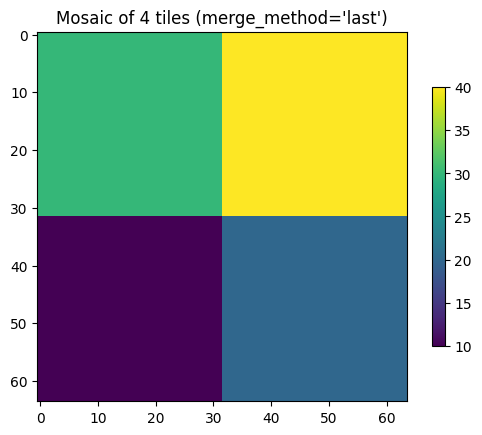

In [7]:
full_aoi = gz.GeoSlice(
    bounds=(500_000, 4_000_000, 500_640, 4_000_640),
    interval=pd.Interval(
        pd.Timestamp("2024-01-15"),
        pd.Timestamp("2024-01-17"),
        closed="both",
    ),
    resolution=(10.0, 10.0),
    crs="EPSG:32629",
)
mosaic = gz.load_raster(catalog, full_aoi, merge_method="last")
print(f"mosaic.values.shape: {mosaic.values.shape}   # (3, 64, 64)")
print(f"mosaic.crs: {mosaic.crs}")

plt.imshow(mosaic.values[0], cmap="viridis")
plt.title("Mosaic of 4 tiles (merge_method='last')")
plt.colorbar(shrink=0.7)
plt.show()

## Time-series stacking

`load_raster_timeseries` walks the catalog day by day and stacks the
daily mosaics along a leading time axis.

series.values.shape: (3, 3, 64, 64)   # (T, 3, 64, 64)
  T = 3 distinct days in the interval


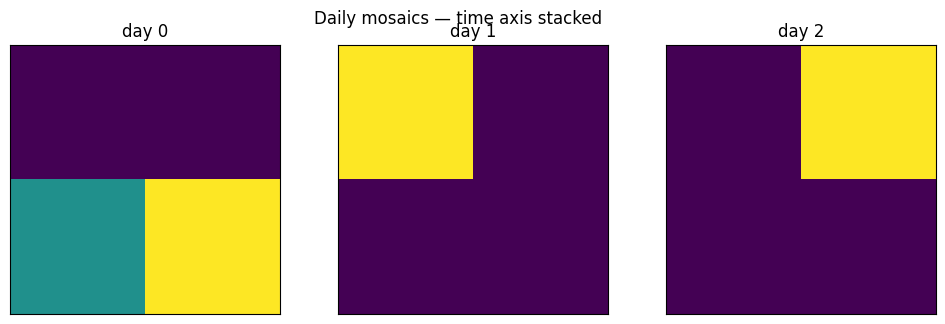

In [8]:
series = gz.load_raster_timeseries(catalog, full_aoi)
print(f"series.values.shape: {series.values.shape}   # (T, 3, 64, 64)")
print(f"  T = {series.values.shape[0]} distinct days in the interval")

fig, axes = plt.subplots(
    1, series.values.shape[0], figsize=(4 * series.values.shape[0], 3.5)
)
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(series.values[i, 0], cmap="viridis")
    ax.set_title(f"day {i}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Daily mosaics — time axis stacked")
plt.show()

## `get_config()`

Every catalog returns a JSON-serialisable summary — handy for logging
and reproducibility audits.

In [9]:
import json


print(json.dumps(catalog.get_config(), indent=2))

{
  "backend": "raster",
  "len": 4,
  "crs": "EPSG:32629"
}
